№1 (2 балла)
Изучите и повторите файл https://cloud.mail.ru/public/RGhr/fkLCPDBp9. Данные можно
взять здесь https://cloud.mail.ru/public/k9mU/SLzTjK1gg.

In [4]:
from narwhals import read_csv
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

In [5]:
import pandas as pd
df = pd.read_excel('knn_data.xlsx')

In [6]:
df

,x1,x2,class
0,-6.005674,-4.854007,1
1,0.937182,-10.939275,1
2,8.158951,-7.719885,1
3,4.814693,-2.841937,1
4,-3.602122,-10.576468,1
...,...,...,...
95,-6.006420,-1.944295,1
96,8.083901,-3.041803,1
97,6.209541,1.918128,1
98,3.243569,-9.595519,0


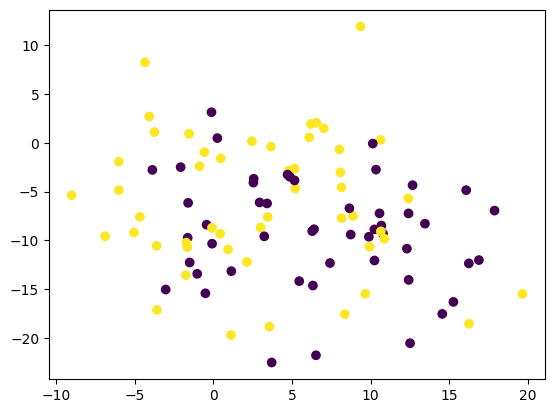

In [7]:
import matplotlib.pyplot as plt
plt.scatter(df['x1'], df['x2'], c = df['class'])

In [8]:
X = df[['x1', 'x2']]
y = df['class']
# Разделим набор данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
neigh = KNeighborsClassifier(n_neighbors=3) # Для примера возьмем 3, можно выбрать другое число и посмотреть как изменится качество
neigh.fit(X_train, y_train)


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [9]:
neigh.score(X_test, y_test) # Доля правильных ответов

0.7

№2 (6 балла)
Выполните задания из файла https://cloud.mail.ru/public/3KMf/xQwX7cbBL.

В этом задании вам нужно подобрать оптимальное значение k для алгоритма kNN. Будем использовать набор данных Wine, где требуется
предсказать сорт винограда, из которого изготовлено вино, используя
результаты химических анализов.


In [10]:

wine_df = pd.read_csv('wine.csv')

wine_df


,1,14.23,1.71,2.43,15.6,127,2.8,3.06,.28,2.29,5.64,1.04,3.92,1065
0,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
1,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
2,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
3,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
4,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
173,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
174,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
175,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


2. Извлеките из данных признаки и классы. Класс записан в первом
столбце (три варианта), признаки — в столбцах со второго по последний. Более подробно о сути признаков можно прочитать по адресу https://archive.ics.uci.edu/ml/datasets/Wine (см. также файл
wine.names, приложенный к заданию)


In [11]:
wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177 entries, 0 to 176
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   1       177 non-null    int64  
 1   14.23   177 non-null    float64
 2   1.71    177 non-null    float64
 3   2.43    177 non-null    float64
 4   15.6    177 non-null    float64
 5   127     177 non-null    int64  
 6   2.8     177 non-null    float64
 7   3.06    177 non-null    float64
 8   .28     177 non-null    float64
 9   2.29    177 non-null    float64
 10  5.64    177 non-null    float64
 11  1.04    177 non-null    float64
 12  3.92    177 non-null    float64
 13  1065    177 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.5 KB


In [12]:
print(wine_df.iloc[:, 0])

0      1
1      1
2      1
3      1
4      1
      ..
172    3
173    3
174    3
175    3
176    3
Name: 1, Length: 177, dtype: int64


In [13]:
print(wine_df.iloc[1:])

     1  14.23  1.71  2.43  15.6  127   2.8  3.06   .28  2.29   5.64  1.04  \
1    1  13.16  2.36  2.67  18.6  101  2.80  3.24  0.30  2.81   5.68  1.03   
2    1  14.37  1.95  2.50  16.8  113  3.85  3.49  0.24  2.18   7.80  0.86   
3    1  13.24  2.59  2.87  21.0  118  2.80  2.69  0.39  1.82   4.32  1.04   
4    1  14.20  1.76  2.45  15.2  112  3.27  3.39  0.34  1.97   6.75  1.05   
5    1  14.39  1.87  2.45  14.6   96  2.50  2.52  0.30  1.98   5.25  1.02   
..  ..    ...   ...   ...   ...  ...   ...   ...   ...   ...    ...   ...   
172  3  13.71  5.65  2.45  20.5   95  1.68  0.61  0.52  1.06   7.70  0.64   
173  3  13.40  3.91  2.48  23.0  102  1.80  0.75  0.43  1.41   7.30  0.70   
174  3  13.27  4.28  2.26  20.0  120  1.59  0.69  0.43  1.35  10.20  0.59   
175  3  13.17  2.59  2.37  20.0  120  1.65  0.68  0.53  1.46   9.30  0.60   
176  3  14.13  4.10  2.74  24.5   96  2.05  0.76  0.56  1.35   9.20  0.61   

     3.92  1065  
1    3.17  1185  
2    3.45  1480  
3    2.93   735  
4  

3. Оценку качества необходимо провести методом кросс-валидации по
5 блокам (5-fold). Создайте генератор разбиений, который перемешивает выборку перед формированием блоков (shuffle=True). Для
воспроизводимости результата, создавайте генератор KFold с фиксированным параметром random_state=42. В качестве меры качества используйте долю верных ответов (accuracy).


In [14]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

knn = KNeighborsClassifier(n_neighbors=5)

cv_scores_knn = cross_val_score(knn, X, y, cv=kf, scoring='accuracy')

print(f"k-NN Cross-Validation Scores: {cv_scores_knn}")
print(f"k-NN Mean Accuracy: {cv_scores_knn.mean()}")

k-NN Cross-Validation Scores: [0.75 0.5  0.45 0.45 0.7 ]
k-NN Mean Accuracy: 0.57


In [15]:
X = wine_df.iloc[:, 1:]
y = wine_df.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, shuffle=True)

4. Найдите точность классификации на кросс-валидации для метода
k ближайших соседей (sklearn.neighbors.KNeighborsClassifier), при
k от 1 до 50. При каком k получилось оптимальное качество? Чему
оно равно (число в интервале от 0 до 1)? Данные результаты и
будут ответами на вопросы 1 и 2.

In [16]:
from sklearn.model_selection import GridSearchCV
import numpy as np

# Определяем диапазон значений k для проверки
param_grid = {'n_neighbors': np.arange(1, 50)}

knn = KNeighborsClassifier()
# Создаем объект GridSearchCV для поиска оптимального k
grid_search = GridSearchCV(knn, param_grid, cv=5)

# Обучаем на тренировочных данных
grid_search.fit(X_train, y_train)

# Выводим лучшее значение k
print(f"Оптимальное значение k: {grid_search.best_params_['n_neighbors']}")
print(f"Лучшая точность при кросс-валидации: {grid_search.best_score_:.4f}")


Оптимальное значение k: 1
Лучшая точность при кросс-валидации: 0.7879


5. Произведите масштабирование признаков с помощью функции
sklearn.preprocessing.scale. Снова найдите оптимальное k на кроссвалидации.


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier()
# Создаем объект GridSearchCV для поиска оптимального k
grid_search_scaled = GridSearchCV(knn, param_grid, cv=5)

# Обучаем на тренировочных данных
grid_search_scaled.fit(X_train_scaled, y_train)

# Выводим лучшее значение k
print(f"Оптимальное значение k: {grid_search_scaled.best_params_['n_neighbors']}")
print(f"Лучшая точность при кросс-валидации: {grid_search_scaled.best_score_:.4f}")

Оптимальное значение k: 9
Лучшая точность при кросс-валидации: 0.9857


6. Какое значение k получилось оптимальным после приведения признаков к одному масштабу? Как изменилось значение качества?
Приведите ответы на вопросы 3 и 4.


Оптимальным значением стало 9
Точность увеличилась с  0.7879 до 0.9857

№3 (4 балла)
Выполните задания из файла https://cloud.mail.ru/public/c9bT/2T4A6yHUN.

1. Загрузите выборку Boston с помощью функции sklearn.datasets.load_boston().
Результатом вызова данной функции является объект, у которого
признаки записаны в поле data, а целевой вектор — в поле target.

In [18]:
import pandas as pd
import numpy as np

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

df = pd.DataFrame(data)
df["PRICE"] = target

df


<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
C:\Users\lidiya\AppData\Local\Temp\ipykernel_1548\4255943014.py:5: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


,0,1,2,3,4,5,6,7,8,9,10,11,12,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0


2. Приведите признаки в выборке к одному масштабу при помощи
функции sklearn.preprocessing.scale.

In [19]:
X = df.drop(columns=["PRICE"])  # все признаки
y = df["PRICE"]                 # целевой признак

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, shuffle=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

3. Переберите разные варианты параметра метрики p по сетке от 1 до
10 с таким шагом, чтобы всего было протестировано 200 вариантов
(используйте функцию numpy.linspace). Используйте KNeighborsRegressor
с n_neighbors=5 и weights=’distance’ — данный параметр добавляет
в алгоритм веса, зависящие от расстояния до ближайших соседей. В
качестве метрики качества используйте среднеквадратичную ошибку (параметр scoring=’mean_squared_error’ у cross_val_score; при
использовании библиотеки scikit-learn версии 18.0.1 и выше необходимо указывать scoring=’neg_mean_squared_error’). Качество оценивайте, как и в предыдущем задании, с помощью кросс-валидации
по 5 блокам с random_state = 42, не забудьте включить перемешивание выборки (shuffle=True).

In [20]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
param_grid = {
'p': np.linspace(1, 10, num=200)}

knn = KNeighborsRegressor(n_neighbors = 5, weights='distance')
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Лучшие параметры: {best_params}")
print(f"RMSE: {np.sqrt(mse)}")
print(f"R²: {r2}")


Лучшие параметры: {'p': np.float64(1.0)}
RMSE: 4.582458387986132
R²: 0.7136527808511335


4. Определите, при каком p качество на кросс-валидации оказалось
оптимальным. Обратите внимание, что cross_val_score возвращает массив показателей качества по блокам; необходимо максимизировать среднее этих показателей. Это значение параметра и будет
ответом на задачу.


In [30]:
best_p = grid_search.best_params_['p']
print(best_p)

1.0
